In [1]:
from google.colab import drive

DRIVE_PATH = '/content/drive'
drive.mount(DRIVE_PATH)


Mounted at /content/drive


# Imports et Configuration

In [2]:
!pip install keras_cv tensorflow_io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 66.7 MB/s eta 0:00:00


In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import time

import keras_cv
import keras
import tensorflow as tf
import tensorflow_io as tfio

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import librosa
import IPython.display as ipd
import librosa.display as lid

import matplotlib.pyplot as plt
import matplotlib as mpl

from google.colab import files
import zipfile

/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZN3tsl7strings13safe_strtou64ESt17basic_string_viewIcSt11char_traitsIcEEPm']
  warnings.warn(

In [5]:
MYDRIVE_PATH = os.path.join(DRIVE_PATH, 'MyDrive/')
TARGET_DIR = os.path.join(MYDRIVE_PATH, 'dsfs-ft-31', 'alzheimer_data/')
print(TARGET_DIR)
TRAIN_AUDIOS_SAMPLE_DIR = os.path.join(TARGET_DIR + 'train_audios_sample/')

TRAIN_AUDIOS_DIR = os.path.join(TARGET_DIR , 'train_audios/')
TEST_AUDIOS_DIR = os.path.join(TARGET_DIR, 'test_audios/')

MODEL_DIR = os.path.join(TARGET_DIR, 'Model/')

TRAIN_AUDIOS_SAMPLE_ZIP_FNAME ='train_audios_sample.zip'
TRAIN_AUDIOS_ZIP_FNAME ='train_audios.zip'
TEST_AUDIOS_ZIP_FNAME ='test_audios.zip'

path_to_zip_file = TRAIN_AUDIOS_SAMPLE_ZIP_FNAME

LABELS_DIR = os.path.join(TARGET_DIR, 'labels/')
TRAIN_LABELS_FILE_PATH = LABELS_DIR + 'train_labels.csv'
METADATA_DIR = LABELS_DIR = os.path.join(TARGET_DIR, 'metadata/')
METADATA_FILE_PATH = METADATA_DIR + 'metadata.csv'
print(f'TRAIN_LABELS_FILE_PATH : {TRAIN_LABELS_FILE_PATH}')

print(f'TRAIN_AUDIOS_DIR : {TRAIN_AUDIOS_DIR}')

/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/
TRAIN_LABELS_FILE_PATH : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/labels/train_labels.csv
TRAIN_AUDIOS_DIR : /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/


In [ ]:
#Load metadata
metadata = files.upload(METADATA_DIR)

Saving metadata.csv to /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/metadata/metadata.csv


In [ ]:
#Load test dataset
test_dataset = files.upload(TARGET_DIR)

Saving test_audios.zip to /content/drive/MyDrive/dsfs-ft-31/alzheimer_data/test_audios.zip


In [6]:


cmap = mpl.cm.get_cmap('coolwarm')

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

class CFG:
    seed = 42

    # Input image size and batch size
    img_size = [128, 384]
    batch_size = 64

    # Audio duration, sample rate, and length
    duration = 30  # secondes
    sample_rate = 32000
    audio_len = duration * sample_rate

    # STFT parameters
    nfft = 2048
    window = 2048
    hop_length = audio_len // 128
    fmin = 20
    fmax = sample_rate // 2

    # Nombre d'époques, modèle
    epochs = 10
    preset = 'efficientnetv2_b2_imagenet'

    # Paramètres d'augmentation des données
    augment = True

    # Chemins des fichiers
    # PFE
    #train_audio_path = '/content/drive/MyDrive/Projects/S-src-wav/train_audios_wav'
    #test_audio_path = '/content/drive/MyDrive/Projects/S-src-wav/test_audios_wav'
    #labels_csv_path = '/content/drive/MyDrive/Projects/S-src-csv-files/train_labels.csv'

    train_audio_path = TRAIN_AUDIOS_DIR
    test_audio_path = TEST_AUDIOS_DIR
    labels_csv_path = TRAIN_LABELS_FILE_PATH

    # Classes de cibles
    class_names = ['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']
    num_classes = len(class_names)
    class_labels = {label: idx for idx, label in enumerate(class_names)}
    label2name = {v: k for k, v in class_labels.items()}

tf.keras.utils.set_random_seed(CFG.seed)



TensorFlow: 2.19.0
Keras: 3.10.0
KerasCV: 0.9.0


/tmp/ipython-input-2182518080.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('coolwarm')


In [16]:
# Chargement des labels
def load_labels():
    labels_df = pd.read_csv(CFG.labels_csv_path)
    return labels_df

def encode_labels(row):
    return [row['diagnosis_control'], row['diagnosis_mci'], row['diagnosis_adrd']]

train_df = load_labels()
# PFE
#metadata_df = pd.read_csv('/content/drive/MyDrive/Projects/S-src-csv-files/metadata.csv')
metadata_df = pd.read_csv(METADATA_FILE_PATH)


train_metadata = metadata_df[metadata_df['split'] == 'train']
test_metadata = metadata_df[metadata_df['split'] == 'test']
train_df = pd.merge(train_metadata, train_df, on='uid', how='inner')

# PFE
#train_df['filepath'] = CFG.train_audio_path + '/' + train_df['uid'].astype(str) + '.wav'
#test_metadata['filepath'] = CFG.test_audio_path + '/' + test_metadata['uid'].astype(str) + '.wav'

train_df['filepath'] = CFG.train_audio_path  + train_df['uid'].astype(str) + '.mp3'
test_metadata['filepath'] = CFG.test_audio_path  + test_metadata['uid'].astype(str) + '.mp3'

train_df['target'] = train_df[['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']].values.tolist()


train, val = train_test_split(
    train_df,
    test_size=0.2,
    random_state=CFG.seed,
    stratify=train_df[['diagnosis_control', 'diagnosis_mci', 'diagnosis_adrd']].apply(
        lambda row: '_'.join(row.astype(str)), axis=1
    )
)

print(f'train shape : {train.shape}')
print(f'val shape : {val.shape}')
train_df.head(5)

train shape : (1316, 11)
val shape : (330, 11)


/tmp/ipython-input-3472873530.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_metadata['filepath'] = CFG.test_audio_path  + test_metadata['uid'].astype(str) + '.mp3'


,uid,age,gender,split,hash,filesize_kb,diagnosis_control,diagnosis_mci,diagnosis_adrd,filepath,target
0,aaop,72,female,train,e4ed5943c8460c2cf324d4a23c7d6fa1,186.144,0.0,1.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/aaop.mp3,"[0.0, 1.0, 0.0]"
1,abgk,80,male,train,c6ca4b23c8a920a6ac950dbec2b58059,136.368,1.0,0.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/abgk.mp3,"[1.0, 0.0, 0.0]"
2,ablf,64,male,train,c646601370d5d8807f6b15d06fd40dd2,139.896,1.0,0.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/ablf.mp3,"[1.0, 0.0, 0.0]"
3,acad,76,female,train,2f0a0eea8caadcc7094af9e91fc88131,290.208,1.0,0.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/acad.mp3,"[1.0, 0.0, 0.0]"
4,acis,87,female,train,410b8b55b4d07ea69d34ec29b6628fd3,301.104,0.0,1.0,0.0,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/acis.mp3,"[0.0, 1.0, 0.0]"


In [15]:
#pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)
val[['uid','split','filepath']].head(10)

,uid,split,filepath
145,cqyj,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/cqyj.mp3
172,dblk,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/dblk.mp3
1267,ucer,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/ucer.mp3
1383,vppw,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/vppw.mp3
630,khso,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/khso.mp3
355,gabp,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/gabp.mp3
1486,xdqh,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/xdqh.mp3
595,jtpj,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/jtpj.mp3
1269,ucsd,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/ucsd.mp3
1098,rkkt,train,/content/drive/MyDrive/dsfs-ft-31/alzheimer_data/train_audios/rkkt.mp3


# Fonctions de Décodage, d'Augmentation et de Construction du Dataset

In [19]:
def build_decoder(dim=CFG.audio_len):
    def get_audio(filepath):
        filepath = tf.compat.as_str_any(filepath.numpy())
        audio, sr = librosa.load(filepath, sr=CFG.sample_rate)
        return audio

    def crop_or_pad(audio, target_len):
        audio_len = len(audio)
        if audio_len < target_len:
            audio = np.pad(audio, (0, target_len - audio_len))
        elif audio_len > target_len:
            audio = audio[:target_len]
        return audio

    def decode(path):
        audio = get_audio(path)
        audio = crop_or_pad(audio, dim)
        spec = librosa.feature.melspectrogram(
            y=audio, sr=CFG.sample_rate, n_mels=256, n_fft=CFG.nfft, hop_length=CFG.hop_length, fmax=CFG.fmax, fmin=CFG.fmin
        )
        spec = librosa.power_to_db(spec, ref=np.max)
        spec = np.expand_dims(spec, axis=-1)
        spec = np.repeat(spec, 3, axis=-1)
        spec = tf.image.resize(spec, CFG.img_size)
        return tf.convert_to_tensor(spec, dtype=tf.float32)

    return decode

def build_augmenter():
    augmenters = [
        keras_cv.layers.MixUp(alpha=0.4),
        keras_cv.layers.RandomCutout(height_factor=(1.0, 1.0), width_factor=(0.06, 0.12)),
        keras_cv.layers.RandomCutout(height_factor=(0.06, 0.1), width_factor=(1.0, 1.0))
    ]
    def augment(img, label):
        data = {"images": img, "labels": label}
        for augmenter in augmenters:
            if tf.random.uniform([]) < 0.35:
                data = augmenter(data, training=True)
        return data["images"], data["labels"]
    return augment

def build_dataset(paths, labels=None, batch_size=32, decode_fn=None, augment_fn=None, shuffle=True):
    if decode_fn is None:
        decode_fn = build_decoder()
    if augment_fn is None:
        augment_fn = build_augmenter()

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def py_decode(path, label):
        decoded_audio = tf.py_function(func=decode_fn, inp=[path], Tout=tf.float32)
        decoded_audio.set_shape([CFG.img_size[0], CFG.img_size[1], 3])
        return decoded_audio, label

    ds = ds.map(py_decode)

    ds = ds.batch(batch_size)
    if shuffle:
        ds = ds.shuffle(buffer_size=1024)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

def build_test_dataset(paths, batch_size=32, decode_fn=None, shuffle=False):
    if decode_fn is None:
        decode_fn = build_decoder()

    ds = tf.data.Dataset.from_tensor_slices(paths)

    def py_decode(path):
        decoded_audio = tf.py_function(func=decode_fn, inp=[path], Tout=tf.float32)
        decoded_audio.set_shape([CFG.img_size[0], CFG.img_size[1], 3])
        return decoded_audio

    ds = ds.map(py_decode)

    ds = ds.batch(batch_size)
    if shuffle:
        ds = ds.shuffle(buffer_size=1024)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

# Construction des Datasets

In [20]:
#train_paths = train_df['filepath'].tolist()
#train_labels = [encode_labels(row) for _, row in train_df.iterrows()]

train_paths = train['filepath'].tolist()
train_labels = [encode_labels(row) for _, row in train.iterrows()]

valid_paths = val['filepath'].tolist()
valid_labels = [encode_labels(row) for _, row in val.iterrows()]

train_ds = build_dataset(train_paths, labels=train_labels, batch_size=CFG.batch_size)
valid_ds = build_dataset(valid_paths, labels=valid_labels, batch_size=CFG.batch_size, shuffle=False)

train_labels[:5]

[[1.0, 0.0, 0.0],
 [1.0, 0.0, 0.0],
 [1.0, 0.0, 0.0],
 [0.0, 0.0, 1.0],
 [1.0, 0.0, 0.0]]

# Modèle et Entraînement

In [21]:
inp = keras.layers.Input(shape=(CFG.img_size[0], CFG.img_size[1], 3))
backbone = keras_cv.models.EfficientNetV2Backbone.from_preset(CFG.preset)
out = keras_cv.models.ImageClassifier(backbone=backbone, num_classes=CFG.num_classes, classifier_kwargs={
        "kernel_regularizer": keras.regularizers.l2(0.01)
    },)(inp)
model = keras.models.Model(inputs=inp, outputs=out)

model.compile(
    optimizer='adam',
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=[keras.metrics.AUC(name='auc'), keras.metrics.CategoricalAccuracy(name='accuracy')]
)
model.summary()


100%|██████████| 1.79k/1.79k [00:00<00:00, 4.53MB/s]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_classifier                │ (None, 3)              │     8,773,601 │
│ (ImageClassifier)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,773,601 (33.47 MB)

 Trainable params: 8,691,313 (33.15 MB)

 Non-trainable params: 82,288 (321.44 KB)

# Callbacks pour l'Entraînement

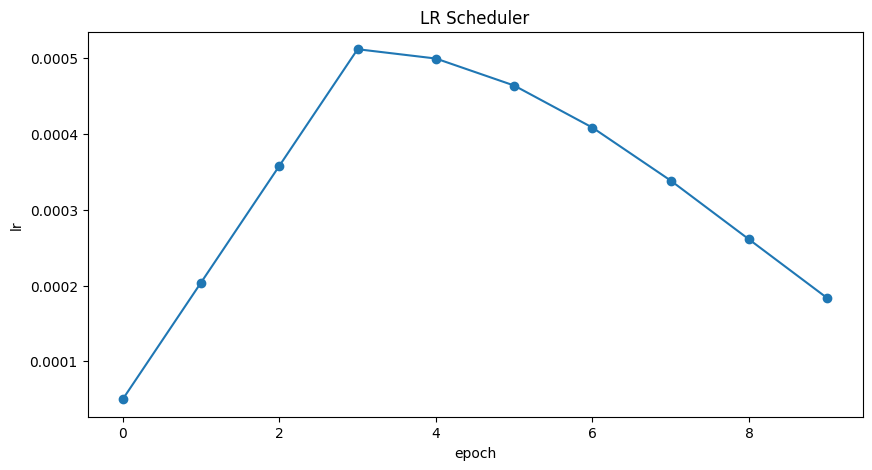

In [23]:
import math

def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 5e-5, 8e-6 * batch_size, 1e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 3, 0, 0.75

    def lrfn(epoch):
        if epoch < lr_ramp_ep:
            lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep:
            lr = lr_max
        elif mode == 'exp':
            lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step':
            lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs = epochs - lr_ramp_ep - lr_sus_ep + 3
            decay_epoch_index = epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch')
        plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn)

lr_cb = get_lr_callback(CFG.batch_size, plot=True)

MODEL_PATH = MODEL_DIR + "EfficientNetV2/best_model.weights.h5"
ckpt_cb = keras.callbacks.ModelCheckpoint(
    MODEL_PATH,
    monitor='val_auc',
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)


# Entraînement du Modèle et Sauvegarde

In [24]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=CFG.epochs,
    callbacks=[lr_cb, ckpt_cb, early_stopping_cb],
    verbose=1
)

# Sauvegarde du modèle au format .keras
MODEL_PATH = MODEL_DIR + "EfficientNetV2/best_model.keras"
model.save(MODEL_PATH)

best_epoch = np.argmax(history.history["val_auc"])
best_score = history.history["val_auc"][best_epoch]
best_accuracy = history.history["val_accuracy"][best_epoch]
print('>>> Best AUC:', best_score)
print('>>> Best Accuracy:', best_accuracy)
print('>>> Best Epoch:', best_epoch + 1)
print('F1-score')

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 608s 22s/step - accuracy: 0.3908 - auc: 0.5836 - loss: 1.0804 - val_accuracy: 0.5394 - val_auc: 0.7266 - val_loss: 1.0027 - learning_rate: 5.0000e-05
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.5443 - auc: 0.7472 - loss: 0.9537 - val_accuracy: 0.5394 - val_auc: 0.7435 - val_loss: 0.9437 - learning_rate: 2.0400e-04
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.5900 - auc: 0.7927 - loss: 0.8593 - val_accuracy: 0.5848 - val_auc: 0.7668 - val_loss: 0.9008 - learning_rate: 3.5800e-04
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.6641 - auc: 0.8586 - loss: 0.7414 - val_accuracy: 0.5879 - val_auc: 0.7646 - val_loss: 0.9090 - learning_rate: 5.1200e-04
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.7893 - auc: 0.9296 - loss: 0.5878 - val_accuracy: 0.5697 - val_auc: 0.7467 - val_loss: 0.9982 - learning_rate: 4.9972e-04
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0

# Visualisation des performances

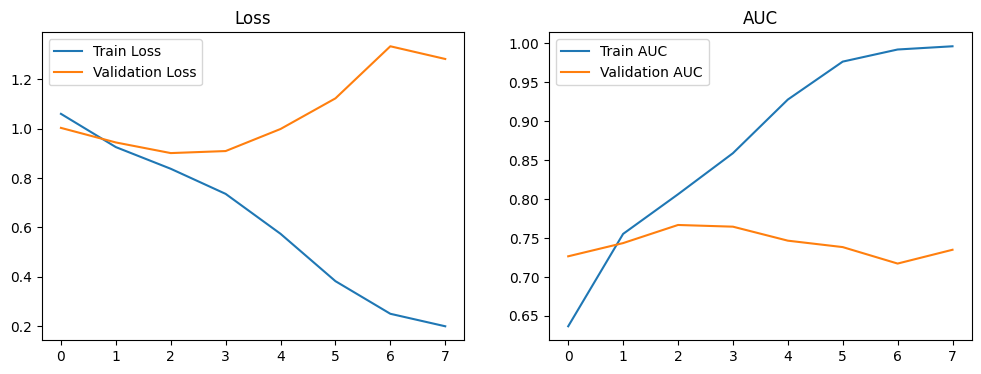

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

# AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.legend()
plt.title('AUC')

plt.show()


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

def display_confusion_matrix(conf_matrix, class_names):
  plt.figure(figsize=(6, 5))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()


def print_classification_report(model:tf.keras.models.Model, X:np.ndarray, y:np.ndarray,class_names):
  y_pred = model.predict(X)
  y_pred_classes = np.argmax(y_pred, axis=1)
  y_true = np.argmax(y, axis=1)

  cm = confusion_matrix(y_true, y_pred_classes)
  print("Confusion matrix:\n")
  display_confusion_matrix(cm,class_names)
  print("\nClassification report:\n", classification_report(y_true, y_pred_classes, digits=3))

In [31]:
print(valid_ds.element_spec)
print(type(valid_ds))

X_val, y_val = [], []

for batch_x, batch_y in valid_ds:
    X_val.append(batch_x.numpy())
    y_val.append(batch_y.numpy())

import numpy as np
X_val = np.concatenate(X_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

print(X_val.shape, y_val.shape)



(TensorSpec(shape=(None, 128, 384, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))
<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(330, 128, 384, 3) (330, 3)


11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Confusion matrix:



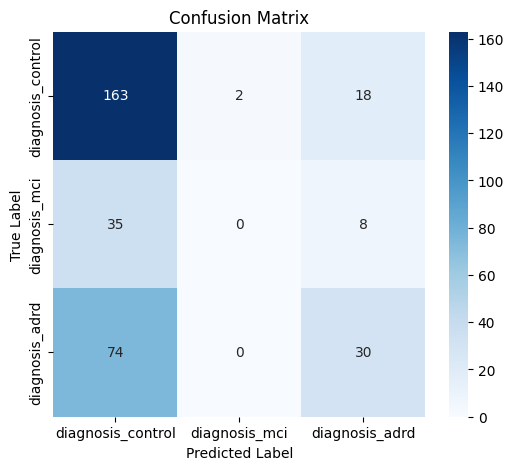


Classification report:
               precision    recall  f1-score   support

           0      0.599     0.891     0.716       183
           1      0.000     0.000     0.000        43
           2      0.536     0.288     0.375       104

    accuracy                          0.585       330
   macro avg      0.378     0.393     0.364       330
weighted avg      0.501     0.585     0.516       330



In [32]:
print_classification_report(model, X_val, y_val, class_names=CFG.class_names)

# Prédictions sur les Données de Test with sanity check

In [ ]:
# Configuration et Préparation des Données de Test
test_metadata['filepath'] = CFG.test_audio_path + '/' + test_metadata['uid'].astype(str) + '.wav'
test_paths = test_metadata['filepath'].tolist()
test_ds = build_test_dataset(test_paths, batch_size=CFG.batch_size)

CURRENT_MODEL_DIR_PATH = MODEL_DIR + "EfficientNetV2/"
# Chargement des poids optimaux
try:
    model.load_weights(CURRENT_MODEL_DIR_PATH + "best_model.weights.h5")
    print("Poids du modèle chargés avec succès.")
except Exception as e:
    print(f"Erreur lors du chargement des poids : {e}")
    exit()

# Prédictions sur les Données de Test
start_time = time.time()
predictions = None
try:
    predictions = model.predict(test_ds)
    print("Prédictions réalisées avec succès.")
except Exception as e:
    print(f"Erreur durant l'inférence : {e}")
    exit()
end_time = time.time()
print(f"Temps total d'inférence : {end_time - start_time:.2f} secondes")

predictions = None

# Vérification des prédictions
if (predictions < 0).any() or (predictions > 1).any():
    print("Attention : Certaines prédictions ne sont pas dans l'intervalle [0, 1].")
else:
    print("Toutes les prédictions sont valides (entre 0 et 1).")

# Préparation du fichier de soumission
submission_df = test_metadata[['uid']].copy()
submission_df['diagnosis_control'] = predictions[:, 0]
submission_df['diagnosis_mci'] = predictions[:, 1]
submission_df['diagnosis_adrd'] = predictions[:, 2]

# Sauvegarde du fichier de soumission

submission_df.to_csv(CURRENT_MODEL_DIR_PATH + 'test_pred.csv', index=False)

# Vérification du fichier final
if os.path.exists(CURRENT_MODEL_DIR_PATH + 'test_pred.csv'):
    print("Fichier de soumission sauvegardé avec succès !")
    print("Aperçu du fichier de soumission :")
    print(submission_df.head())
else:
    print("Erreur : le fichier de soumission n'a pas été créé.")


NameError: name 'CFG' is not defined